In [1]:
import numpy as np
import os
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

def load_and_flatten(directory):
    images, labels = [], []
    classes = sorted(os.listdir(directory))
    for i, label in enumerate(classes):
        path = os.path.join(directory, label)
        for img_name in os.listdir(path):
            img = tf.keras.utils.load_img(os.path.join(path, img_name), 
                                         color_mode="grayscale", target_size=(48,48))
            images.append(tf.keras.utils.img_to_array(img).flatten())
            labels.append(i)
    return np.array(images) / 255.0, np.array(labels), classes

X_train_flat, y_train, class_names = load_and_flatten('archive/train')
X_test_flat, y_test, _ = load_and_flatten('archive/test')

# Calculate Class Weights to fix the 31% accuracy "short-cut"
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
dict_weights = dict(enumerate(weights))

print(f"Weights calculated: {dict_weights}")

Weights calculated: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [2]:
# Cell 2: No PCA - Direct 2D Reshaping
import numpy as np

# --- PCA Commented Out ---
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_flat)
# X_test_scaled = scaler.transform(X_test_flat)
# pca = PCA(n_components=512, whiten=True)
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)
# -------------------------

# 1. Reshape the raw flat data back into 48x48 images
X_train_cnn = X_train_flat.reshape(-1, 48, 48, 1)
X_test_cnn = X_test_flat.reshape(-1, 48, 48, 1)

print(f"Data ready for Raw CNN: {X_train_cnn.shape[1:]} shape")

Data ready for Raw CNN: (48, 48, 1) shape


In [3]:
import tensorflow as tf

# Load the 'intelligence' back into the variable 'model'
try:
    model = tf.keras.models.load_model('improved_model.h5')
    print("Model restored successfully!")
except Exception as e:
    print(f"Error: Could not find 'improved_model.h5'. Check your folder. {e}")

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

Model restored successfully!


In [ ]:
#dont run
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

no_of_classes = 7

model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), padding='same', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2)) # Lower dropout at the start to help it learn

# Block 2
model.add(Conv2D(128, (5,5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block 3
model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block 4
model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(Dropout(0.2))

model.add(Flatten())

# Fully connected layers
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(Dropout(0.5))

model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(Dropout(0.5))

model.add(Dense(no_of_classes, activation='softmax'))

# Reset learning rate to 0.001 to "kickstart" the learning
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

d:\Projects\Pattern Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,017,671 (30.58 MB)

 Trainable params: 8,013,703 (30.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 1. FIX THE VALUEERROR: Re-compile the model with a fresh optimizer
# This links the optimizer to your CURRENT model variables
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 2. Setup the Augmentation Generator
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 3. Apply Augmentation to Training Data (48x48 Raw Pixels)
train_generator = train_datagen.flow(X_train_cnn, y_train, batch_size=32)

# 4. Define Callbacks
checkpointer = ModelCheckpoint(
    'improved_model.h5', 
    verbose=1, 
    save_best_only=True, 
    monitor='val_accuracy'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=0.00001,
    verbose=1
)

# 5. Start Training
history = model.fit(
    train_generator,
    validation_data=(X_test_cnn, y_test),
    epochs=50,
    class_weight=dict_weights,
    callbacks=[checkpointer, reduce_lr]
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5851 - loss: 1.0418
Epoch 1: val_accuracy improved from None to 0.60267, saving model to improved_model.h5



Epoch 1: finished saving model to improved_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 357s 389ms/step - accuracy: 0.5795 - loss: 1.0658 - val_accuracy: 0.6027 - val_loss: 1.0817 - learning_rate: 0.0010
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.5753 - loss: 1.0674
Epoch 2: val_accuracy did not improve from 0.60267
898/898 ━━━━━━━━━━━━━━━━━━━━ 344s 383ms/step - accuracy: 0.5719 - loss: 1.0879 - val_accuracy: 0.6013 - val_loss: 1.0567 - learning_rate: 0.0010
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.5745 - loss: 1.0755
Epoch 3: val_accuracy did not improve from 0.60267
898/898 ━━━━━━━━━━━━━━━━━━━━ 369s 411ms/step - accuracy: 0.5734 - loss: 1.0826 - val_accuracy: 0.5999 - val_loss: 1.0845 - learning_rate: 0.0010
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.5710 - loss: 1.0783
Epoch 4: val_accuracy improved from 0.60267 to 0.61605, saving model to improved_model.h5



Epoch 4: finished saving model to improved_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 340s 379ms/step - accuracy: 0.5730 - loss: 1.0855 - val_accuracy: 0.6160 - val_loss: 1.0366 - learning_rate: 0.0010
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5760 - loss: 1.0728
Epoch 5: val_accuracy did not improve from 0.61605
898/898 ━━━━━━━━━━━━━━━━━━━━ 353s 393ms/step - accuracy: 0.5748 - loss: 1.0817 - val_accuracy: 0.5900 - val_loss: 1.1054 - learning_rate: 0.0010
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5804 - loss: 1.0546
Epoch 6: val_accuracy did not improve from 0.61605
898/898 ━━━━━━━━━━━━━━━━━━━━ 349s 388ms/step - accuracy: 0.5792 - loss: 1.0684 - val_accuracy: 0.5833 - val_loss: 1.1226 - learning_rate: 0.0010
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.5754 - loss: 1.0898
Epoch 7: val_accuracy did not improve from 0.61605
898/898 ━━━━━━━━━━━━━━━━━━━━ 345s 384ms/step - accuracy: 0.5804 - loss: 1.0667 - val_accuracy: 


Epoch 10: finished saving model to improved_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 334s 372ms/step - accuracy: 0.5969 - loss: 1.0136 - val_accuracy: 0.6259 - val_loss: 1.0135 - learning_rate: 5.0000e-04


225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step
Classification Report:

              precision    recall  f1-score   support

       Angry       0.53      0.59      0.56       958
     Disgust       0.42      0.72      0.53       111
        Fear       0.50      0.40      0.45      1024
       Happy       0.91      0.76      0.83      1774
         Sad       0.54      0.68      0.60      1233
    Surprise       0.52      0.47      0.49      1247
     Neutral       0.71      0.81      0.76       831

    accuracy                           0.63      7178
   macro avg       0.59      0.63      0.60      7178
weighted avg       0.64      0.63      0.63      7178



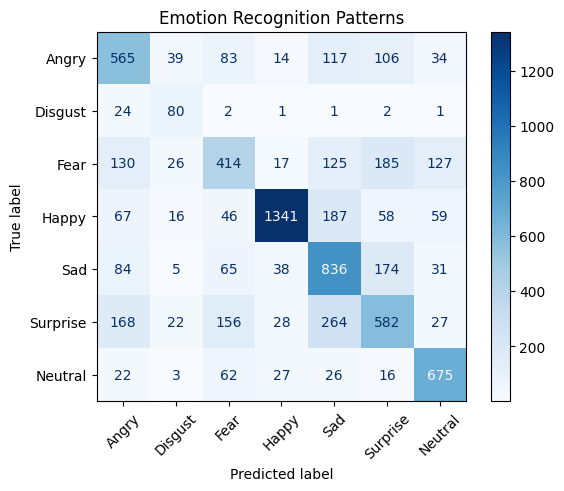

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Get predictions for the test set
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Define emotion labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# 3. Print Accuracy Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=emotion_labels))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Emotion Recognition Patterns")
plt.show()

In [6]:
import cv2
import numpy as np

# --- Setup ---
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv2.VideoCapture(0)
# cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
# cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# --- New: Full Screen Window Setup ---
# window_name = 'Raw CNN Emotion Detection'
# cv2.namedWindow(window_name, cv2.WND_PROP_FULLSCREEN)
# cv2.setWindowProperty(window_name, cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

while True:
    ret, frame = cap.read()
    if not ret: break

    # --- New: Mirror Mode ---
    # Flip horizontally (1) so your right is the screen's right
    frame = cv2.flip(frame, 1)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_gray = cv2.resize(roi_gray, (48, 48))
        
        # Normalize and reshape directly to 48x48
        cnn_input = roi_gray.reshape(1, 48, 48, 1) / 255.0

        # Prediction
        prediction = model.predict(cnn_input, verbose=0)
        emotion = emotion_labels[np.argmax(prediction)]

        # Drawing
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, emotion, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow(window_name, frame)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()